# SHO Fitting

This notebook completes the SHO fitting using the conventional algorithms in Pycroscopy. 

## Import Packages

In [1]:
# # For the notebook to work you must have m3_learning installed
# # pip install m3_learning
%load_ext autoreload
%autoreload 2

from m3util.viz.printing import printer
from m3util.viz.style import set_style
from m3util.ml.rand import set_seeds
from m3util.util.IO import download_and_unzip
from belearn.dataset.dataset import BE_Dataset
from belearn.dataset.State import State
from belearn.viz.viz import Viz

import numpy as np

# from m3_learning.be.dataset import BE_Dataset
printing = printer(basepath = './Figures/')

set_style("printing")
set_seeds(seed=42)

ModuleNotFoundError: No module named 'autophyslearn'

## Loading data for SHO fitting


In [2]:
# Download the data file from Zenodo
url = 'https://zenodo.org/record/7774788/files/PZT_2080_raw_data.h5?download=1'

# Specify the filename and the path to save the file
# filename = 'data_raw.h5'
filename = 'data_raw.h5'
save_path = './Data'

# download the file
download_and_unzip(filename, url, save_path)

Using files already downloaded


In [4]:
data_path = save_path + '/' + filename

# instantiate the dataset object
dataset = BE_Dataset(data_path)

# print the contents of the file
dataset.print_be_tree()

TypeError: 'list' object is not callable

## Visualize Raw Data

### Raw Cantilever Response


In [4]:
dataset.num_bins

165

In [19]:
dataset.frequency_bin

array([1229492.2, 1230468.8, 1231445.2, 1232421.9, 1233398.5, 1234375. ,
       1235351.5, 1236328.1, 1237304.8, 1238281.2, 1239257.8, 1240234.4,
       1241211. , 1242187.5, 1243164. , 1244140.6, 1245117.2, 1246093.8,
       1247070.2, 1248046.9, 1249023.5, 1250000. , 1250976.5, 1251953.1,
       1252929.8, 1253906.2, 1254882.8, 1255859.4, 1256836. , 1257812.5,
       1258789. , 1259765.6, 1260742.2, 1261718.8, 1262695.2, 1263671.9,
       1264648.5, 1265625. , 1266601.5, 1267578.1, 1268554.8, 1269531.2,
       1270507.8, 1271484.4, 1272461. , 1273437.5, 1274414. , 1275390.6,
       1276367.2, 1277343.8, 1278320.2, 1279296.9, 1280273.5, 1281250. ,
       1282226.5, 1283203.1, 1284179.8, 1285156.2, 1286132.8, 1287109.4,
       1288086. , 1289062.5, 1290039. , 1291015.6, 1291992.2, 1292968.8,
       1293945.2, 1294921.9, 1295898.5, 1296875. , 1297851.5, 1298828.1,
       1299804.8, 1300781.2, 1301757.8, 1302734.4, 1303711. , 1304687.5,
       1305664. , 1306640.6, 1307617.2, 1308593.8, 

In [15]:
# insatiate the visualization object
image_scalebar = [2000, 500, "nm", "br"]

BE_viz = Viz(dataset, printing, verbose=True, 
             SHO_ranges = [(0,1.5e-4), (1.31e6, 1.33e6), (-300, 300), (-np.pi, np.pi)], 
             image_scalebar = image_scalebar)

/home/jca92/miniconda3/envs/m3/lib/python3.11/site-packages/m3util/viz/layout.py:284: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=wspace, hspace=hspace)


TypeError: unhashable type: 'BE_Dataset'

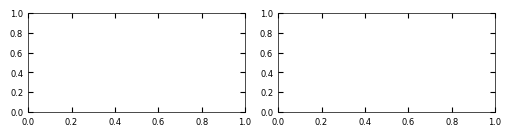

In [16]:
prediction = {"resampled": False,
              "label": "Raw"}

BE_viz.raw_data_comparison(prediction, filename="Figure_2_1_raw_cantilever_response_test")

In [17]:
BE_viz.dataset

BE_Dataset(file='./Data/data_raw.h5', noise=0)

In [10]:
BE_viz.measurement_state


AttributeError: 'Viz' object has no attribute 'measurement_state'

In [20]:
if np.isscalar(165) or len(165) == 1:
    print("Y")

Y


**Figure 2.1** Raw cantilever response. a) magnitude spectrum and Phase, b) real and imaginary parts of the complex spectrum.


### Band-Excitation Experiments

./Figures/Figure_2_2_raw_be_experiment.png
./Figures/Figure_2_2_raw_be_experiment.svg


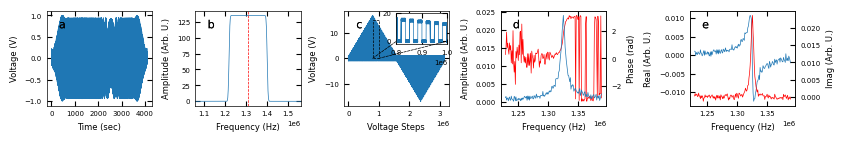

In [8]:
BE_viz.raw_be(dataset, filename="Figure_2_2_raw_be_experiment")

**Figure 2.2** Band-Excitation Experiments. a) raw drive amplitude applied to the tip, b) energy of the waveform in the frequency domain, c) DC voltage applied to switch the sample, inset shows a zoomed in view of the switching waveform where measurements are made in the on and off state. d) raw cantilever response magnitude and phase, e) real and imaginary parts of the complex spectrum.

## SHO Fitting
**Note**: this code takes around 15 minutes to execute

If you downloaded the SHO fit data, or ran notebook 1 you do not need to fit the data again. 

You can skip to the next section.

If you would like to run this code block please change the Fit_SHO flag to `True`

In [9]:
Fit_SHO = False

if Fit_SHO: 

    # # computes the SHO fit for the data in the file
    dataset.SHO_Fitter(force = True)
    
    # instantiate the dataset object
    # good to reinstantiate the dataset object after fitting
    dataset = BE_Dataset(data_path)

### Views the Distribution of the Least Squares Fitting (LSQF) results

It is good to view the distributions and standardize the phase shift. The phase shift is rotated around the unit circle such that the peaks are at $-\pi/2$ and $\pi/2$

current_SHO_ranges: [(0, 0.00015), (1310000.0, 1330000.0), (-300, 300), (-3.141592653589793, 3.141592653589793)]
current_dataset_state: {'raw_format': 'complex', 'fitter': 'LSQF', 'scaled': False, 'output_shape': 'pixels', 'measurement_state': 'all', 'LSQF_phase_shift': 0, 'NN_phase_shift': None, 'noise': 0, 'loop_interpolated': False}
./Figures/Figure_3_Original_LSQF_Histograms.png
./Figures/Figure_3_Original_LSQF_Histograms.svg


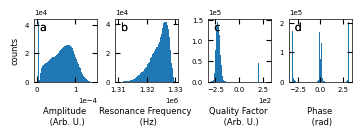

In [10]:
dataset.LSQF_phase_shift = 0

BE_viz.SHO_hist(dataset.SHO_fit_results(),
                      filename="Figure_2_3_Original_LSQF_Histograms")


**Figure 2.3** Distribution of the Least Squares Fitting (LSQF) results of the unmodified data. a) Distribution of the amplitude, b) Distribution of the resonance frequency, c) distribution of the quality factor, d) distribution of the resonance frequency.

current_SHO_ranges: [(0, 0.00015), (1310000.0, 1330000.0), (-300, 300), (-3.141592653589793, 3.141592653589793)]
current_dataset_state: {'raw_format': 'complex', 'fitter': 'LSQF', 'scaled': False, 'output_shape': 'pixels', 'measurement_state': 'all', 'LSQF_phase_shift': 1.5707963267948966, 'NN_phase_shift': None, 'noise': 0, 'loop_interpolated': False}
./Figures/Figure_4_Phase_Shifted_LSQF_Histograms.png
./Figures/Figure_4_Phase_Shifted_LSQF_Histograms.svg


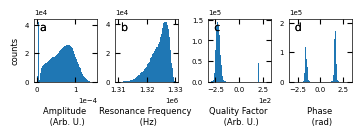

In [11]:
dataset.LSQF_phase_shift = np.pi/2

BE_viz.SHO_hist(dataset.SHO_fit_results(),
                      filename="Figure_4_Phase_Shifted_LSQF_Histograms")

**Figure 2.4** Distribution of the Least Squares Fitting (LSQF) results of the normalized data. a) Distribution of the amplitude, b) distribution of the resonance frequency, c) distribution of the quality factor, d) distribution of the resonance frequency.

### Plots the SHO Fit Results

./Figures/Figure_5_Single_Pixel_Loops.png
./Figures/Figure_5_Single_Pixel_Loops.svg


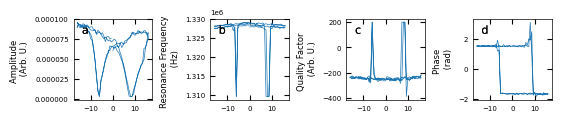

In [12]:
BE_viz.dataset.measurement_state = 'on'

BE_viz.SHO_loops(filename="Figure_2_5_Single_Pixel_Loops")

**Figure 2_5.** Example switching loops obtained for the amplitude, resonance frequency, quality factor, and phase.

## SHO Switching Movies

In [13]:
BE_viz.SHO_fit_movie_images(noise = 0, 
                            scalebar_= True, 
                            basepath = "Movies/SHO_LSQF_",  
                            filename="SHO_LSQF",
                            phase_shift = [np.pi/2])

Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0000.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0001.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0002.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0003.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0004.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0005.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0006.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0007.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0008.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0009.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0010.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0011.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0012.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0013.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0014.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0015.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0016.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0017.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0018.png
Movies/SHO_LSQF_Noise_0/SHO_LSQF_noise_0_0019.png


100%|██████████████| 192/192 [00:27<00:00,  7.11it/s]
